# Grid-based stratification — Burnt

Alternative to the **severity-quantile** train/val/test split already used for the locked dataset
(`repackage_agdamage_ootd.ipynb` / `update_split.py`): instead of stratifying `dev` events by an
event-level severity quantile bin, this notebook stratifies by a **spatial grid cell**. Everything
upstream of the split is unchanged and reused as-is:

- Same event-level severity aggregation (`severity_mean`, `severity_ivw`).
- Same **cross-region OOD hold-out** (South Africa for Burnt — already chosen from the top-5
  candidates on min 20 events / representative severity / isolation ≥ 50km, capped at ~12% of
  events). OOD is carved out *before* any train/val/test split, same as always.
- Same 60:20:20 ratios, same seed (42), same event-atomicity guarantee.

Only the **strata definition** for the dev-remainder split changes: grid cell instead of severity
quantile bin. Purpose: compare the two before locking the dataset. Run for **Burnt** first; copy
this notebook for **Flood** (swap `INPUT_PATHS` / `OOD_REGIONS` / hazard name in the config cell —
the country-inference cell is already written to matter for Flood's sparsely-geocoded
`groundsource` chips).

In [1]:
# ============================== CONFIG (edit) ==============================
from pathlib import Path
INPUT_PATHS       = ["/fs/ess/PGS0413/AgDamage_Benchmark_v2/Burnt/manifest.parquet"]
OUTPUT_DIR        = "out/stratification_by_grid_burnt"

RATIOS            = (0.6, 0.2, 0.2)     # train : val : test (events, on the non-OOD remainder) -- same as the severity-quantile pipeline
SEED              = 42

DEFAULT_SIZE      = 512
MIN_CROPLAND_FRAC = 0.0
SEVERITY_COL      = "severity_ivw"      # used only for the balance-check plots, not for the split itself

# --- cross-region OOD hold-out: already decided, reused as-is (see repackage_agdamage_ootd.ipynb) ---
OOD_UNIT          = "country"
OOD_REGIONS       = {"burnt": ["South Africa"]}

# --- grid knobs ---
GRID_SIZE_DEG        = 10.0   # base equal-width lon/lat cell size, degrees
MIN_EVENTS_PER_CELL  = 15     # sparse cells get folded into their nearest neighbor until every stratum clears this floor

SEVERITY_FIELD_BY_HAZARD = {
    "flood": "flooded_crop_frac", "burnt": "burned_crop_frac",
    "burned": "burned_crop_frac", "fire": "burned_crop_frac",
}

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

def _read(p):
    p = str(p); return pd.read_parquet(p) if p.endswith((".parquet", ".pq")) else pd.read_csv(p)

df = pd.concat([_read(p) for p in INPUT_PATHS], ignore_index=True)
print(f"Loaded {len(df):,} chips | {df['event_id'].nunique():,} events | hazards: {sorted(df['hazard'].dropna().unique())}")
df.head()

Loaded 4,786 chips | 1,463 events | hazards: ['Burnt']


,chip_id,event_id,rank,source,tier,continent,country,place,event_date_start,event_date_end,crs,res_m,size,cropland_frac,excluded_crop_frac,burned_crop_frac,burned_crop_px,burn_severity_mean,min_lon,min_lat,max_lon,max_lat,hazard,shard,has_s1,phenology_stage,qc_verdict,severity_mean,severity_ivw,severity_class,subset,split
0,MC202000392449_r0065_c0134,MC202000392449,2,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,EPSG:32631,10,512,0.4763,0.0000,0.4048,106125,2.64,2.581529,7.064411,2.627931,7.110764,Burnt,burnt-000100.tar,True,dormant,clean,0.40978,0.427849,q3,dev,test
1,MC202000392449_r0067_c0187,MC202000392449,5,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,EPSG:32631,10,512,0.4629,0.0000,0.3248,85138,2.70,2.629526,7.062642,2.675923,7.108991,Burnt,burnt-000055.tar,True,dormant,clean,0.40978,0.427849,q3,dev,test
2,MC202000392449_r0079_c0239,MC202000392449,1,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,EPSG:32631,10,512,0.6769,0.0008,0.5907,154858,3.04,2.676623,7.051822,2.723015,7.098167,Burnt,burnt-000115.tar,True,dormant,minor,0.40978,0.427849,q3,dev,test
3,MC202000392449_r0107_c0303,MC202000392449,4,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,EPSG:32631,10,512,0.3687,0.0000,0.3547,92989,3.12,2.734593,7.026530,2.780977,7.072869,Burnt,burnt-000057.tar,True,dormant,clean,0.40978,0.427849,q3,dev,test
4,MC202000392449_r0130_c0205,MC202000392449,3,mcd64-cluster,A,Africa,Benin,Benin,2020-02-01,2020-02-28,EPSG:32631,10,512,0.4557,0.0570,0.3739,98030,2.93,2.645869,7.005666,2.692260,7.052014,Burnt,burnt-000034.tar,True,dormant,minor,0.40978,0.427849,q3,dev,test


## Infer missing `country` for `groundsource` chips (offline reverse geocoding)

No-op for Burnt — `country` is already 100% populated there. Kept identical to
`repackage_agdamage_ootd.ipynb` so this cell needs **zero edits** when copied for Flood, whose
`groundsource` chips are only ~8% geocoded and would otherwise silently break a country-based OOD
carve.

In [3]:
import geopandas as gpd
NE_COUNTRIES_SHP = "naturalearth/ne_50m_admin_0_countries.shp"

def infer_country_from_latlon(df, shp_path=NE_COUNTRIES_SHP):
    df = df.copy()
    need = df["country"].isna() & (df.get("source") == "groundsource")
    if "centroid_lon" in df.columns:
        clon, clat = df["centroid_lon"], df["centroid_lat"]
    else:
        clon, clat = (df["min_lon"] + df["max_lon"]) / 2, (df["min_lat"] + df["max_lat"]) / 2
    need &= clon.notna() & clat.notna()
    df["country_inferred"] = False
    if not need.any():
        return df
    countries = gpd.read_file(shp_path)[["NAME", "CONTINENT", "geometry"]]
    pts = gpd.GeoDataFrame({"idx": df.index[need]}, geometry=gpd.points_from_xy(clon[need], clat[need]), crs="EPSG:4326")
    joined = gpd.sjoin(pts, countries, how="left", predicate="within").drop_duplicates("idx").set_index("idx")
    unmatched = joined[joined["NAME"].isna()]
    if len(unmatched):
        pts_m = pts.set_index("idx").to_crs(3857)
        countries_m = countries.to_crs(3857)
        nearest = gpd.sjoin_nearest(pts_m.loc[unmatched.index, ["geometry"]], countries_m, how="left")
        nearest = nearest[~nearest.index.duplicated(keep="first")]
        joined.loc[nearest.index, "NAME"] = nearest["NAME"]
    df.loc[joined.index, "country"] = joined["NAME"]
    df.loc[joined.index, "country_inferred"] = joined["NAME"].notna()
    return df

df = infer_country_from_latlon(df)
n_inferred = int(df["country_inferred"].sum())
print(f"Inferred country for {n_inferred:,} groundsource chips from lat/lon; "
      f"{int(df['country'].isna().sum()):,} chips still have no country.")

Inferred country for 0 groundsource chips from lat/lon; 0 chips still have no country.


## Event-level severity + centroid (unchanged from the severity-quantile pipeline)

`severity_mean`/`severity_ivw` aren't used to *define* the grid split, but they're carried through
so the balance-check plots later on can verify the grid split still reasonably represents the
severity distribution even though it isn't the stratification variable.

In [4]:
def resolve_damage_frac(row):
    if "damage_frac" in df.columns and pd.notna(row.get("damage_frac")): return row["damage_frac"]
    fld = SEVERITY_FIELD_BY_HAZARD.get(str(row["hazard"]).lower())
    if fld and fld in df.columns and pd.notna(row.get(fld)): return row[fld]
    for f in ("flooded_crop_frac", "burned_crop_frac", "damaged_crop_frac"):
        if f in df.columns and pd.notna(row.get(f)): return row[f]
    return np.nan

df["damage_frac"] = df.apply(resolve_damage_frac, axis=1).astype(float)
size = df["size"] if "size" in df.columns else DEFAULT_SIZE
df["cropland_px"] = (df["cropland_frac"].astype(float) * (np.asarray(size) ** 2)).round()
gated = df[df["cropland_frac"].astype(float) >= MIN_CROPLAND_FRAC].copy()
print(f"Gate MIN_CROPLAND_FRAC={MIN_CROPLAND_FRAC}: kept {len(gated):,}/{len(df):,} chips")

# ---- aggregate chips -> events: severity (mean & IVW) + geography + centroid ----
g = gated.dropna(subset=["damage_frac"]).copy()
g["w"] = g["cropland_px"].clip(lower=0); g["wf"] = g["w"] * g["damage_frac"]
if "centroid_lon" not in g.columns and {"min_lon", "max_lon"} <= set(g.columns):
    g["centroid_lon"] = (g["min_lon"] + g["max_lon"]) / 2
    g["centroid_lat"] = (g["min_lat"] + g["max_lat"]) / 2
for c in ("centroid_lon", "centroid_lat"):
    if c not in g.columns: g[c] = np.nan
aggd = {"n_chips": ("damage_frac", "size"), "severity_mean": ("damage_frac", "mean"),
        "_ws": ("w", "sum"), "_wf": ("wf", "sum"),
        "centroid_lon": ("centroid_lon", "mean"), "centroid_lat": ("centroid_lat", "mean")}
for col in ("country", "continent"):
    if col in g.columns: aggd[col] = (col, "first")
events = g.groupby(["event_id", "hazard"], as_index=False).agg(**aggd)
events["severity_ivw"] = np.where(events["_ws"] > 0, events["_wf"] / events["_ws"], np.nan)
events = events.drop(columns=["_ws", "_wf"])
print(f"{len(events):,} events aggregated")
events.head()

Gate MIN_CROPLAND_FRAC=0.0: kept 4,786/4,786 chips
1,463 events aggregated


,event_id,hazard,n_chips,severity_mean,centroid_lon,centroid_lat,country,continent,severity_ivw
0,MC202000392449,Burnt,5,0.409780,2.676825,7.065388,Benin,Africa,0.427849
1,MC202000946606,Burnt,4,0.432875,124.243416,39.927715,"Korea, North",EastAsia,0.455914
2,MC202000981039,Burnt,4,0.094325,29.711889,-14.083055,Zambia,Africa,0.091779
3,MC202001003906,Burnt,2,0.647250,39.138247,36.999715,Turkey,Europe,0.647733
4,MC202001224756,Burnt,5,0.846540,75.353536,30.776160,India,SouthAsia,0.846483


## Cross-region OOD hold-out — reused, not recomputed

South Africa was already selected for Burnt (min 20 events, representative severity, ≥50km
isolation, ≤12% of events — see `repackage_agdamage_ootd.ipynb`'s candidate-ranking cell for the
full research table). This notebook is only about the dev-remainder split, so it simply reapplies
that decision rather than re-running candidate search.

In [5]:
events["subset"] = "dev"
for hz, regs in (OOD_REGIONS or {}).items():
    if OOD_UNIT in events.columns:
        m = (events["hazard"].astype(str).str.lower() == hz.lower()) & (events[OOD_UNIT].isin(list(regs)))
        events.loc[m, "subset"] = "ood_holdout"
print(events.groupby(["hazard", "subset"]).size().to_string())

hazard  subset     
Burnt   dev            1441
        ood_holdout      22


## Grid-based stratification

Build a **fixed-width lon/lat grid** (`GRID_SIZE_DEG`) over the `dev` events' centroids — a literal
grid, as opposed to the equal-*count* severity-quantile bins used elsewhere. Burnt event density is
extremely non-uniform (Africa alone is ~45% of dev events, with large sparse gaps elsewhere), so a
fixed grid at any reasonable cell size leaves most raw cells too small to carry their own
60:20:20 split. `merge_sparse_cells` repeatedly folds the smallest under-populated cell into its
nearest neighbor (population-weighted centroid distance) until every stratum clears
`MIN_EVENTS_PER_CELL` — the same spirit as merging small blocks in spatial block cross-validation
(Roberts et al. 2017, already cited in this project's methodology) rather than dropping them.
Within each final stratum, events are seeded-shuffled and ratio-sliced into train/val/test —
identical mechanics to the severity-quantile split, just keyed by grid stratum instead of severity
quantile bin.

In [1]:
def _haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    d = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(d))

def build_grid(dev: pd.DataFrame, cell_size_deg: float) -> pd.DataFrame:
    """Assign each dev event to a fixed-size lon/lat grid cell. Equal-width
    cells -- this is the literal 'grid' in grid-based stratification, as
    opposed to the equal-count severity-quantile bins used elsewhere."""
    dev = dev.copy()
    lon_idx = np.floor((dev["centroid_lon"] - dev["centroid_lon"].min()) / cell_size_deg).astype(int)
    lat_idx = np.floor((dev["centroid_lat"] - dev["centroid_lat"].min()) / cell_size_deg).astype(int)
    dev["cell_id"] = lon_idx.astype(str) + "_" + lat_idx.astype(str)
    return dev

def merge_sparse_cells(dev: pd.DataFrame, min_events: int) -> pd.DataFrame:
    """Fixed-width cells are wildly uneven here (dense hotspots vs. sparse
    coverage elsewhere), so most raw cells can't carry a meaningful
    train/val/test split alone. Repeatedly fold the smallest under-populated
    cell into its nearest neighbor (by population-weighted centroid distance)
    until every remaining stratum has >= min_events -- same spirit as
    spatial block-CV (Roberts et al. 2017) merging small blocks rather than
    dropping them."""
    stats = (dev.groupby("cell_id")
             .agg(n=("cell_id", "size"), lon=("centroid_lon", "mean"), lat=("centroid_lat", "mean"))
             .to_dict("index"))
    parent = {c: c for c in stats}
    while True:
        small = [c for c, v in stats.items() if v["n"] < min_events]
        if not small or len(stats) == 1:
            break
        c = min(small, key=lambda x: stats[x]["n"])
        others = [o for o in stats if o != c]
        nearest = min(others, key=lambda o: _haversine_km(stats[c]["lon"], stats[c]["lat"], stats[o]["lon"], stats[o]["lat"]))
        n1, n2 = stats[c]["n"], stats[nearest]["n"]
        stats[nearest] = {
            "n": n1 + n2,
            "lon": (stats[c]["lon"] * n1 + stats[nearest]["lon"] * n2) / (n1 + n2),
            "lat": (stats[c]["lat"] * n1 + stats[nearest]["lat"] * n2) / (n1 + n2),
        }
        for k, v in parent.items():
            if v == c: parent[k] = nearest
        del stats[c]
    dev = dev.copy()
    dev["grid_cell"] = dev["cell_id"].map(parent)
    return dev

dev_events = events[events["subset"] == "dev"].copy()
dev_events = build_grid(dev_events, GRID_SIZE_DEG)
n_raw_cells = dev_events["cell_id"].nunique()
dev_events = merge_sparse_cells(dev_events, MIN_EVENTS_PER_CELL)
n_final_cells = dev_events["grid_cell"].nunique()
cell_sizes = dev_events["grid_cell"].value_counts().sort_values()
print(f"Grid: {GRID_SIZE_DEG:.0f}\u00b0  raw cells={n_raw_cells}  -> merged (min {MIN_EVENTS_PER_CELL}/stratum) -> {n_final_cells} strata")
print(cell_sizes.describe())

events = events.merge(dev_events[["event_id", "grid_cell"]], on="event_id", how="left")

NameError: name 'pd' is not defined

### Grid construction — dev events, base cells, and merged strata

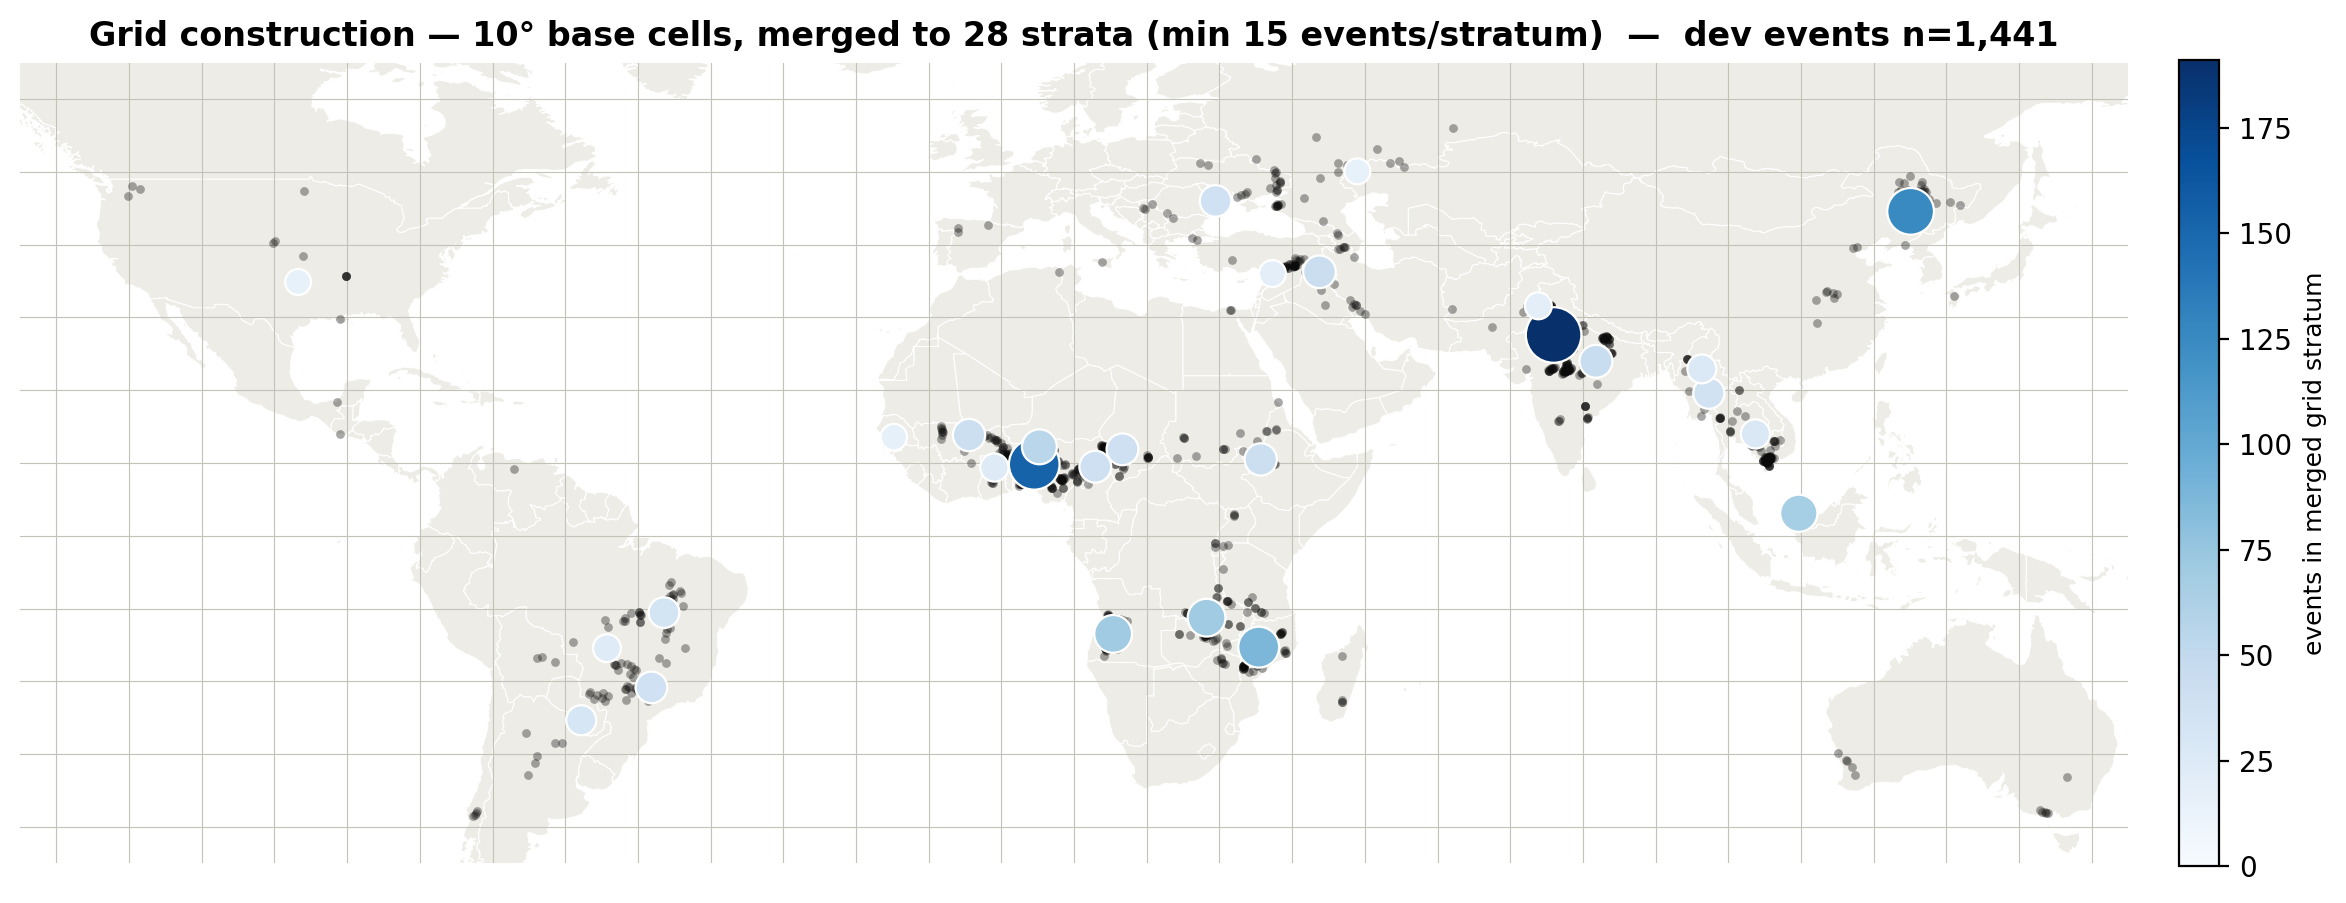

In [ ]:
import geopandas as gpd

SPLIT_COLOR = {"train": "#2a78d6", "val": "#1baf7a", "test": "#eb6834"}
OOD_COLOR   = "#52514e"
GRID_LINE_COLOR = "#c3c2b7"
SEQ_BLUE = plt.get_cmap("Blues")

world = gpd.read_file(NE_COUNTRIES_SHP)

def basemap(ax):
    world.plot(ax=ax, color="#eeece6", edgecolor="white", linewidth=0.4, zorder=1)
    ax.set_xlim(-135, 155); ax.set_ylim(-45, 65)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)

dev = dev_events
fig, ax = plt.subplots(figsize=(13, 6.5))
basemap(ax)
lon0, lat0 = dev["centroid_lon"].min(), dev["centroid_lat"].min()
lon1, lat1 = dev["centroid_lon"].max(), dev["centroid_lat"].max()
for x in np.arange(np.floor(lon0 / GRID_SIZE_DEG) * GRID_SIZE_DEG, lon1 + GRID_SIZE_DEG, GRID_SIZE_DEG):
    ax.axvline(x, color=GRID_LINE_COLOR, linewidth=0.4, zorder=2)
for y in np.arange(np.floor(lat0 / GRID_SIZE_DEG) * GRID_SIZE_DEG, lat1 + GRID_SIZE_DEG, GRID_SIZE_DEG):
    ax.axhline(y, color=GRID_LINE_COLOR, linewidth=0.4, zorder=2)
clu = dev.groupby("grid_cell").agg(n=("event_id", "size"), lon=("centroid_lon", "mean"), lat=("centroid_lat", "mean"))
vmax = clu["n"].max()
ax.scatter(dev["centroid_lon"], dev["centroid_lat"], s=10, color="#0b0b0b", alpha=0.35, zorder=3, linewidths=0)
sc2 = ax.scatter(clu["lon"], clu["lat"], s=60 + 340 * clu["n"] / vmax, c=clu["n"], cmap=SEQ_BLUE,
                  edgecolor="white", linewidth=0.8, zorder=4, vmin=0, vmax=vmax)
cbar = fig.colorbar(sc2, ax=ax, shrink=0.65, pad=0.02)
cbar.set_label("events in merged grid stratum", fontsize=9)
ax.set_title(f"Grid construction \u2014 {GRID_SIZE_DEG:.0f}\u00b0 base cells, merged to {n_final_cells} strata "
             f"(min {MIN_EVENTS_PER_CELL} events/stratum)  \u2014  dev events n={len(dev):,}",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/01_grid_construction.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Stratified split within each grid cell

Same seeded shuffle-and-ratio-slice as the severity-quantile pipeline (`_alloc`), just keyed by
`grid_cell` instead of `severity_class`.

In [8]:
rng = np.random.default_rng(SEED)

def _alloc(n, r):
    n_tr = int(round(n * r[0])); n_va = int(round(n * r[1])); n_te = n - n_tr - n_va
    if n_te < 0: n_va += n_te; n_te = 0
    return n_tr, n_va, n_te

event_split = {}
for cell, grp in dev_events.groupby("grid_cell"):
    ids = grp["event_id"].tolist(); rng.shuffle(ids)
    n_tr, n_va, n_te = _alloc(len(ids), RATIOS)
    for i, e in enumerate(ids):
        event_split[e] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")

events["split_grid"] = events["event_id"].map(event_split)
events.loc[events["subset"] == "ood_holdout", "split_grid"] = "ood_holdout"

keep = ["event_id", "grid_cell", "severity_mean", "severity_ivw", "subset", "split_grid"]
drop_cols = [c for c in ("grid_cell", "severity_mean", "severity_ivw", "subset", "split", "severity_class") if c in df.columns]
df_base = df.drop(columns=drop_cols)  # drop the manifest's original severity/subset/split/severity_class so the merge doesn't collide
manifest_grid = df_base.merge(events[keep], on="event_id", how="left").rename(columns={"split_grid": "split"})
print("events per split (grid):\n", events["split_grid"].value_counts(dropna=False).to_string())
print("\nchips per split (grid):\n", manifest_grid["split"].value_counts(dropna=False).to_string())

# event-atomic leakage check
ev_bad = events.groupby("event_id")["split_grid"].nunique()
ch_bad = manifest_grid.groupby("event_id")["split"].nunique()
leaked = sorted(set(ev_bad[ev_bad > 1].index) | set(ch_bad[ch_bad > 1].index))
assert len(leaked) == 0, f"LEAKAGE: {leaked[:10]}"
print("Event-atomic check PASSED.")

manifest_grid.to_parquet(f"{OUTPUT_DIR}/manifest_grid.parquet", index=False)
manifest_grid.to_csv(f"{OUTPUT_DIR}/manifest_grid.csv", index=False)
print("wrote manifest_grid.{parquet,csv} ->", OUTPUT_DIR)

events per split (grid):
 split_grid
train          862
test           291
val            288
ood_holdout     22

chips per split (grid):
 split
train          2828
val             961
test            926
ood_holdout      71
Event-atomic check PASSED.
wrote manifest_grid.{parquet,csv} -> out/stratification_by_grid_burnt


## Compare to the current severity-quantile split

Same events, same OOD hold-out, two different train/val/test assignments of the dev remainder —
side by side on a map.

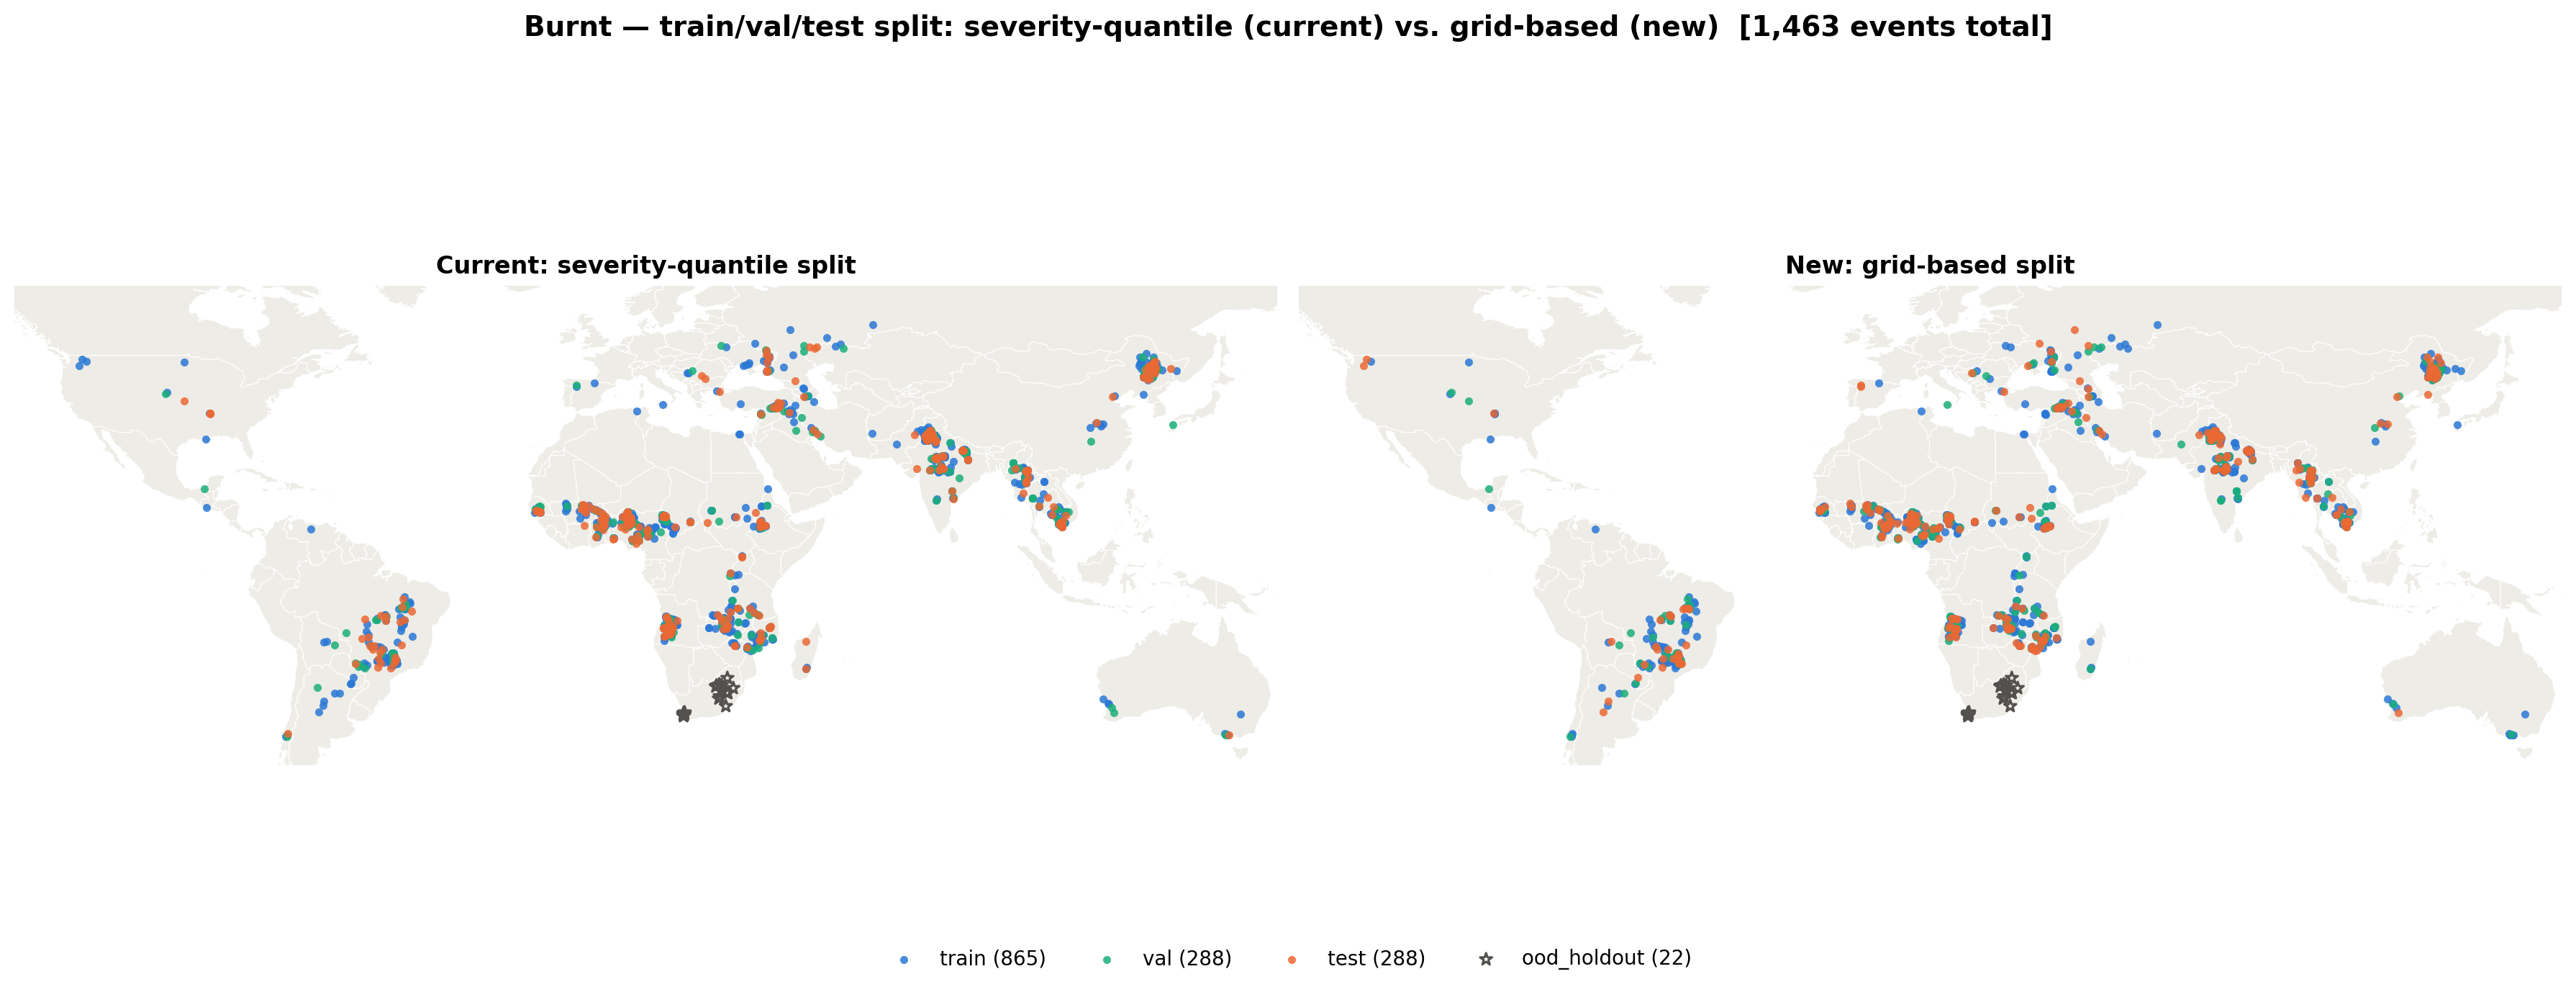

In [9]:
orig = pd.read_parquet(INPUT_PATHS[0])
orig_ev = orig.groupby("event_id").agg(
    split=("split", "first"),
    min_lon=("min_lon", "mean"), max_lon=("max_lon", "mean"),
    min_lat=("min_lat", "mean"), max_lat=("max_lat", "mean"),
).reset_index()
orig_ev["clon"] = (orig_ev.min_lon + orig_ev.max_lon) / 2
orig_ev["clat"] = (orig_ev.min_lat + orig_ev.max_lat) / 2
grid_ev = events.copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
for ax, (title, tbl, lon_c, lat_c, split_c) in zip(axes, [
    ("Current: severity-quantile split", orig_ev, "clon", "clat", "split"),
    ("New: grid-based split", grid_ev, "centroid_lon", "centroid_lat", "split_grid"),
]):
    basemap(ax)
    for sp, color in SPLIT_COLOR.items():
        sub = tbl[tbl[split_c] == sp]
        ax.scatter(sub[lon_c], sub[lat_c], s=16, color=color, alpha=0.85, linewidth=0, zorder=3, label=f"{sp} ({len(sub)})")
    ood = tbl[tbl[split_c] == "ood_holdout"]
    ax.scatter(ood[lon_c], ood[lat_c], s=40, facecolor="none", edgecolor=OOD_COLOR, linewidth=1.1,
               marker="*", zorder=4, label=f"ood_holdout ({len(ood)})")
    ax.set_title(title, fontsize=12, fontweight="bold")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Burnt \u2014 train/val/test split: severity-quantile (current) vs. grid-based (new)  [{len(events):,} events total]",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/02_split_comparison_map.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Sanity check — is severity still reasonably represented?

The grid split isn't stratified on severity at all, so this checks it hasn't accidentally skewed
severity across splits.

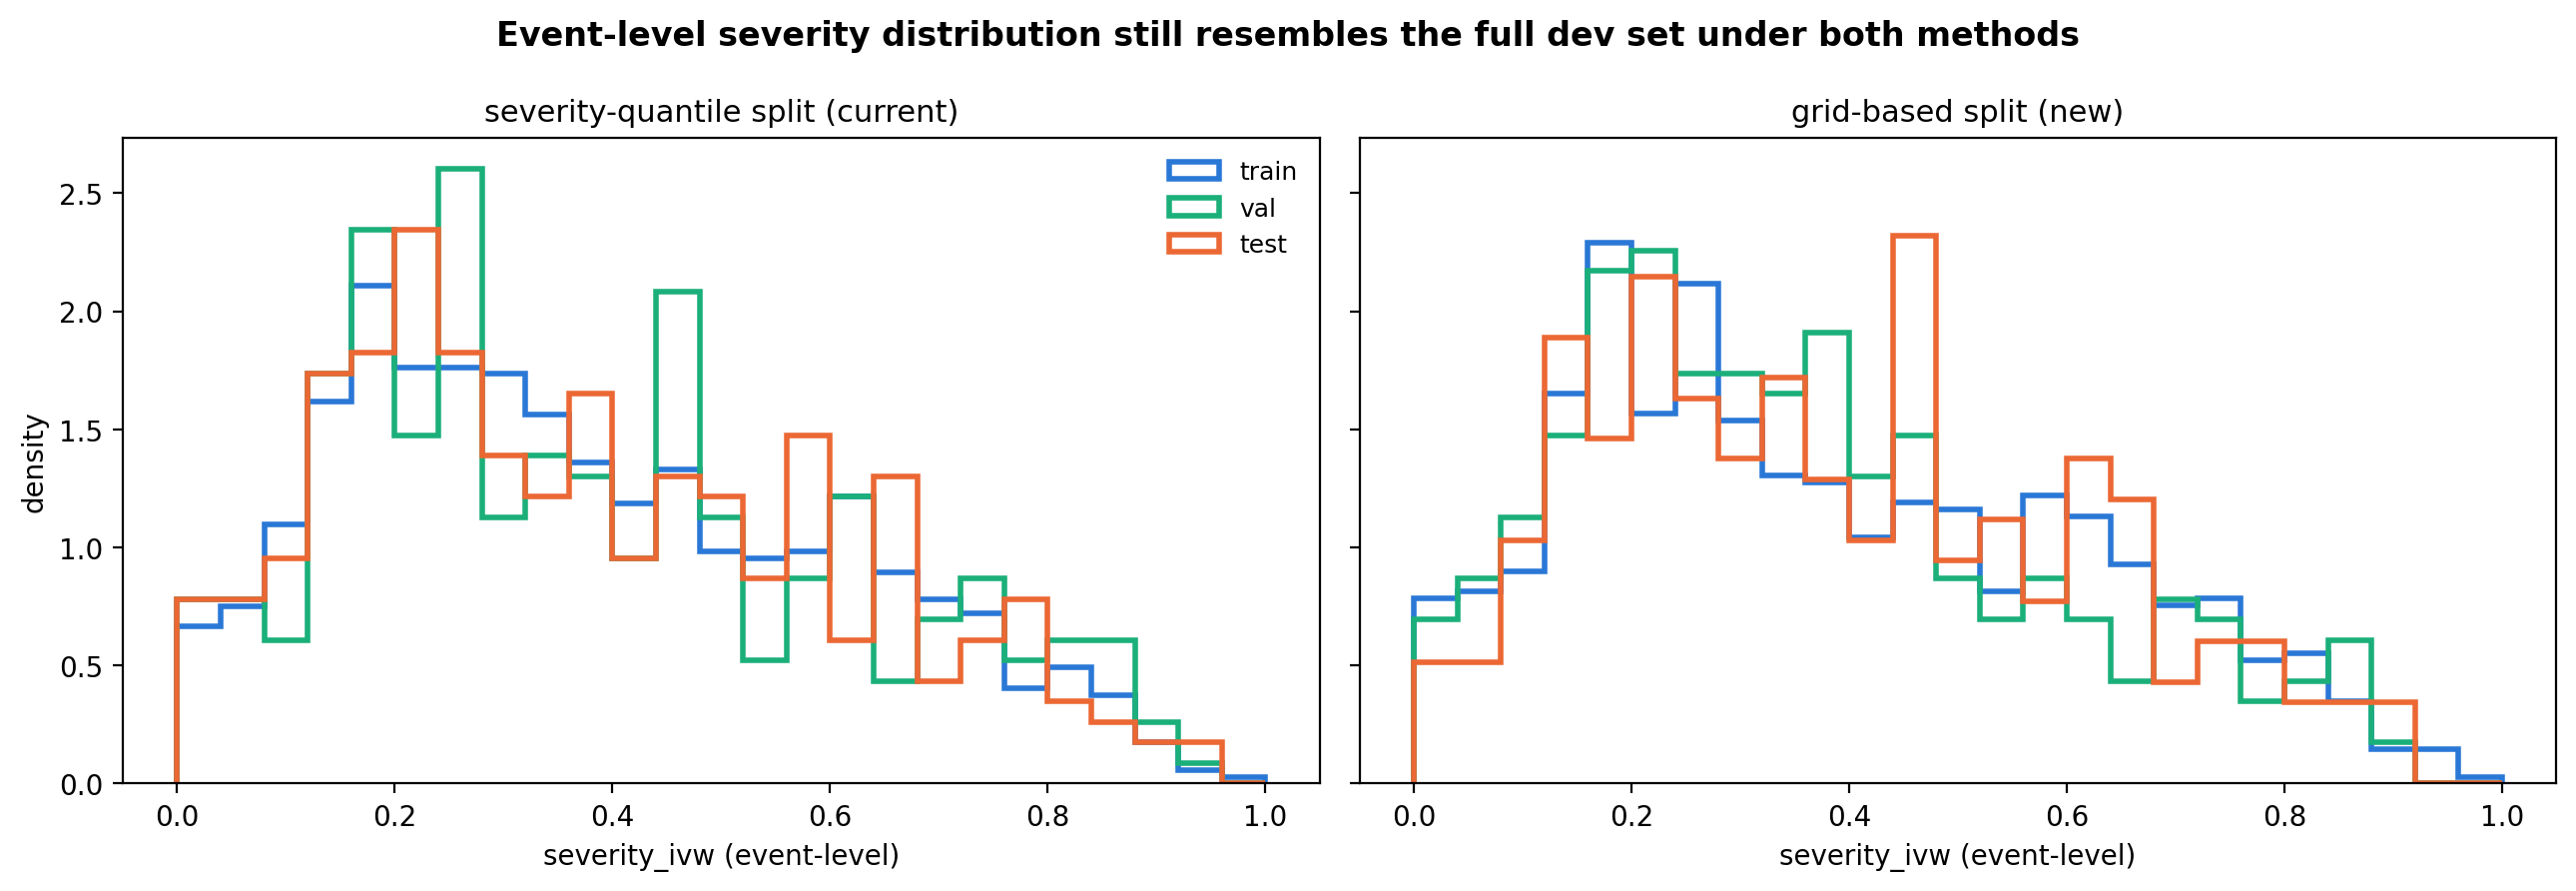

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
orig_sev = orig.groupby("event_id").agg(split=("split", "first"), severity_ivw=("severity_ivw", "first")).reset_index()
for ax, (title, tbl, split_c) in zip(axes, [
    ("severity-quantile split (current)", orig_sev, "split"),
    ("grid-based split (new)", grid_ev.rename(columns={"split_grid": "split_new"}), "split_new"),
]):
    for sp, color in SPLIT_COLOR.items():
        vals = tbl[tbl[split_c] == sp]["severity_ivw"].dropna()
        ax.hist(vals, bins=25, range=(0, 1), histtype="step", linewidth=2, color=color, label=sp, density=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("severity_ivw (event-level)")
axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Event-level severity distribution still resembles the full dev set under both methods", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/03_severity_by_split.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Per-stratum train/val/test composition

Confirms the 60:20:20 ratio holds within every grid stratum, not just in aggregate.

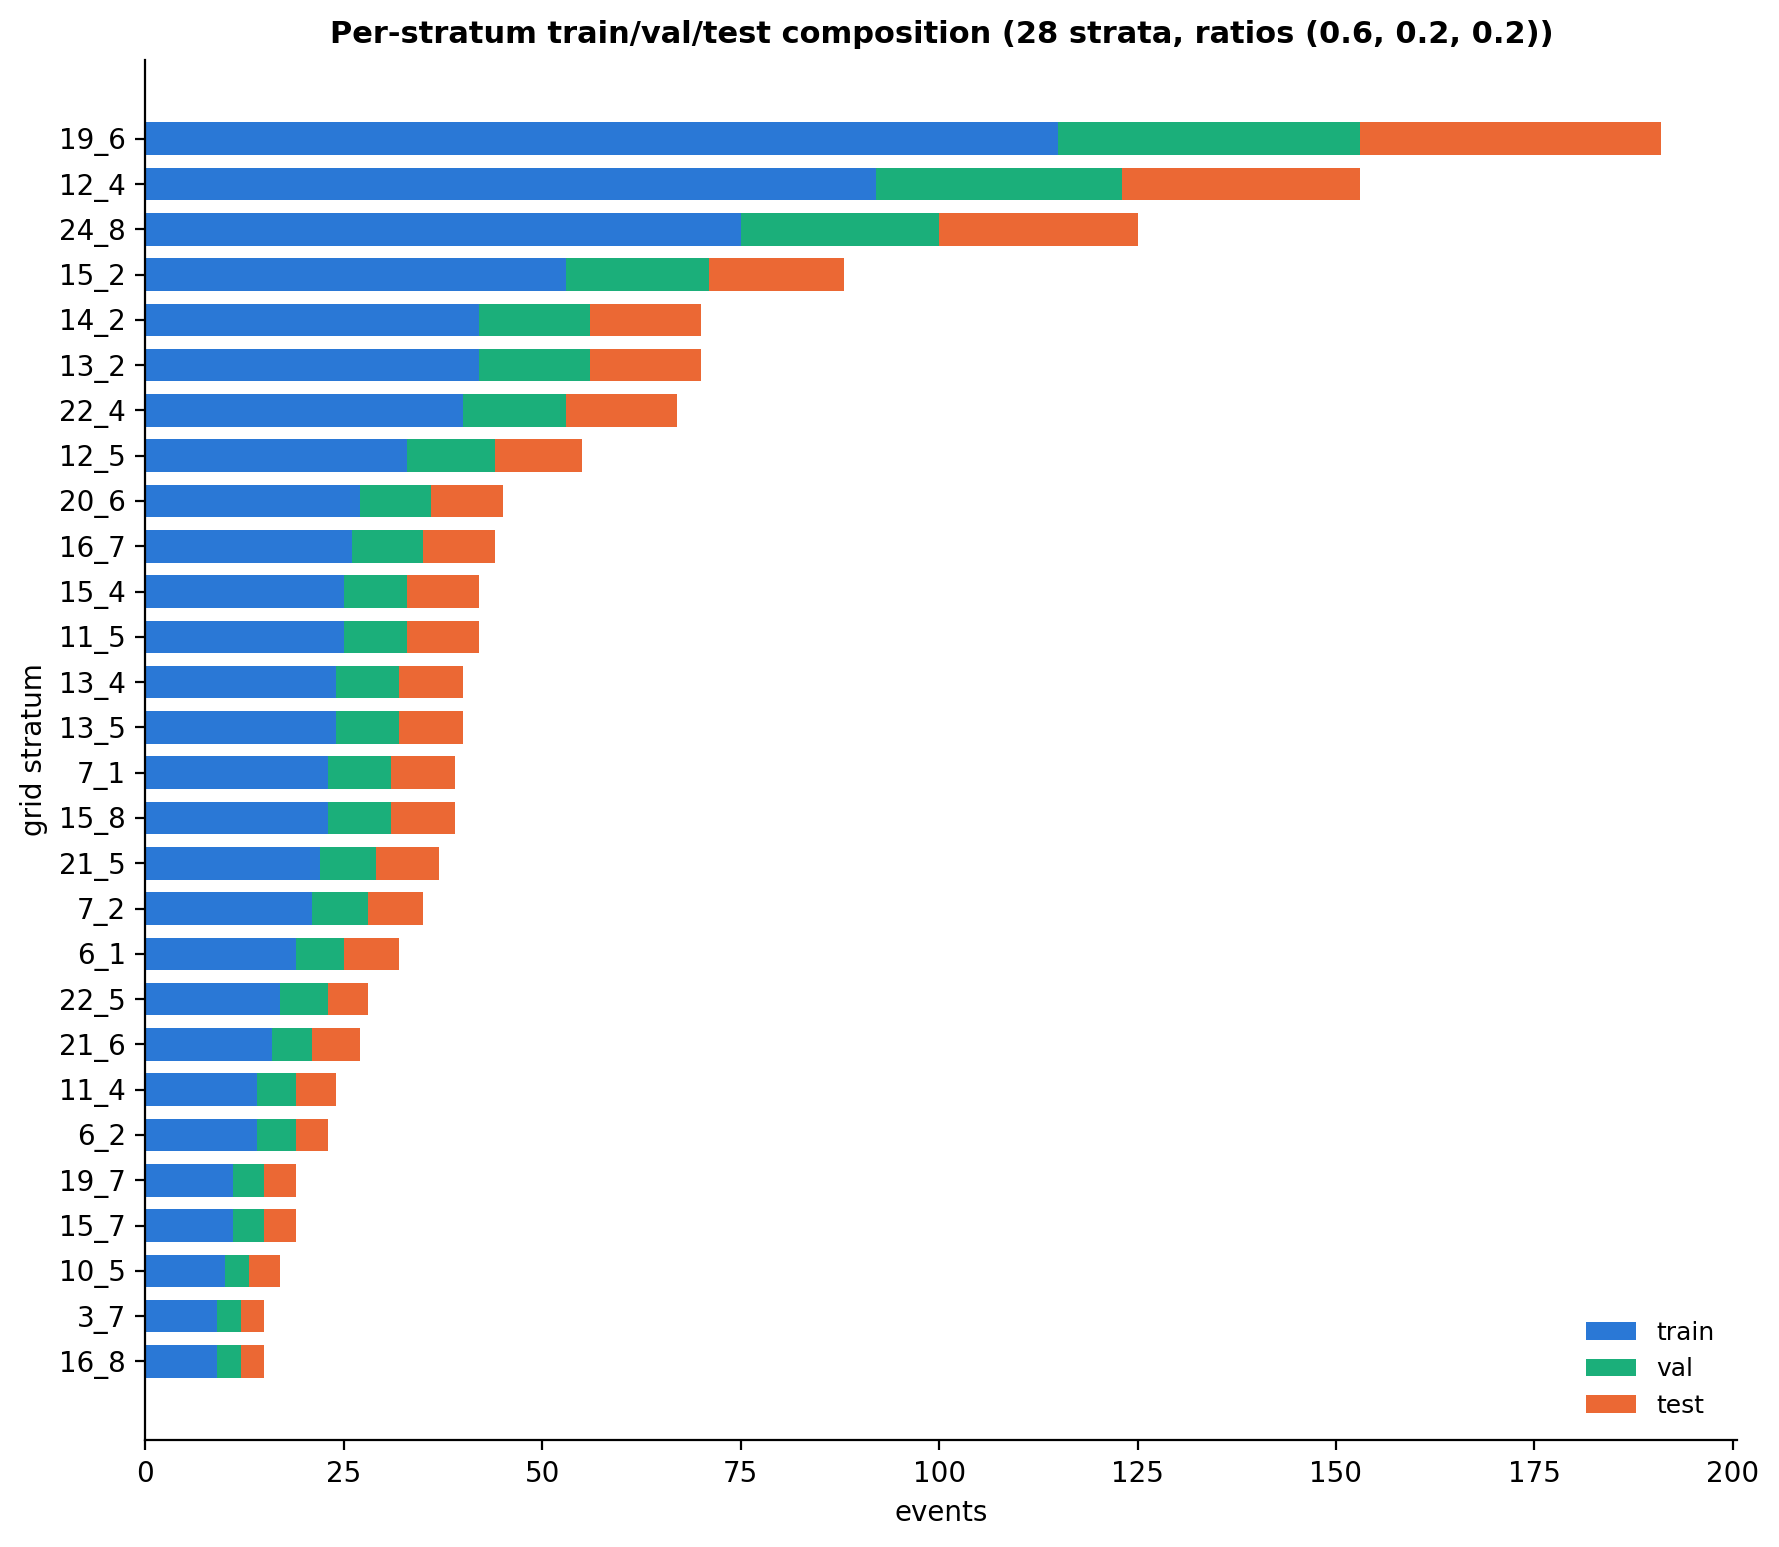

In [11]:
comp = (dev.assign(split=dev["event_id"].map(event_split))
        .groupby(["grid_cell", "split"]).size().unstack(fill_value=0))
comp = comp.reindex(columns=["train", "val", "test"], fill_value=0)
comp["n"] = comp.sum(axis=1)
comp = comp.sort_values("n", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, 0.28 * len(comp))))
left = np.zeros(len(comp))
for sp in ["train", "val", "test"]:
    ax.barh(comp.index.astype(str), comp[sp], left=left, color=SPLIT_COLOR[sp], label=sp, height=0.72)
    left += comp[sp].values
ax.set_xlabel("events"); ax.set_ylabel("grid stratum")
ax.set_title(f"Per-stratum train/val/test composition ({len(comp)} strata, ratios {RATIOS})", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=9, loc="lower right")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/04_per_stratum_composition.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Balance trade-off — Wasserstein distances (severity vs. spatial)

Quantifies the story from the maps above: cutting strata on geography instead of severity should
tighten the train/val/test spatial distributions (lower lon/lat Wasserstein = splits look more
alike geographically) at some cost to how tightly severity is balanced across splits.

In [12]:
def wasserstein1d(a, b, n=1000):
    a = np.sort(np.asarray(a, float)); b = np.sort(np.asarray(b, float))
    if len(a) == 0 or len(b) == 0: return np.nan
    q = np.linspace(0, 1, n)
    return float(np.mean(np.abs(np.quantile(a, q) - np.quantile(b, q))))

rows = []
for method, tbl_sev, tbl_geo, split_col in [
    ("severity-quantile (current)", orig_sev, orig_ev, "split"),
    ("grid-based (new)", grid_ev, grid_ev, "split_grid"),
]:
    parts_sev = {sp: tbl_sev[tbl_sev[split_col] == sp]["severity_ivw"].values for sp in ("train", "val", "test")}
    lon_col = "clon" if "clon" in tbl_geo.columns else "centroid_lon"
    lat_col = "clat" if "clat" in tbl_geo.columns else "centroid_lat"
    parts_lon = {sp: tbl_geo[tbl_geo[split_col] == sp][lon_col].values for sp in ("train", "val", "test")}
    parts_lat = {sp: tbl_geo[tbl_geo[split_col] == sp][lat_col].values for sp in ("train", "val", "test")}
    rows.append(dict(
        method=method,
        severity_wass_tr_te=wasserstein1d(parts_sev["train"], parts_sev["test"]),
        severity_wass_tr_va=wasserstein1d(parts_sev["train"], parts_sev["val"]),
        lon_wass_tr_te=wasserstein1d(parts_lon["train"], parts_lon["test"]),
        lon_wass_tr_va=wasserstein1d(parts_lon["train"], parts_lon["val"]),
        lat_wass_tr_te=wasserstein1d(parts_lat["train"], parts_lat["test"]),
        lat_wass_tr_va=wasserstein1d(parts_lat["train"], parts_lat["val"]),
    ))
balance = pd.DataFrame(rows).set_index("method")
balance.round(4)

,severity_wass_tr_te,severity_wass_tr_va,lon_wass_tr_te,lon_wass_tr_va,lat_wass_tr_te,lat_wass_tr_va
method,,,,,,
severity-quantile (current),0.0054,0.0097,5.3953,2.2829,0.8775,0.9292
grid-based (new),0.0160,0.0218,1.1305,0.9476,0.6577,0.4930


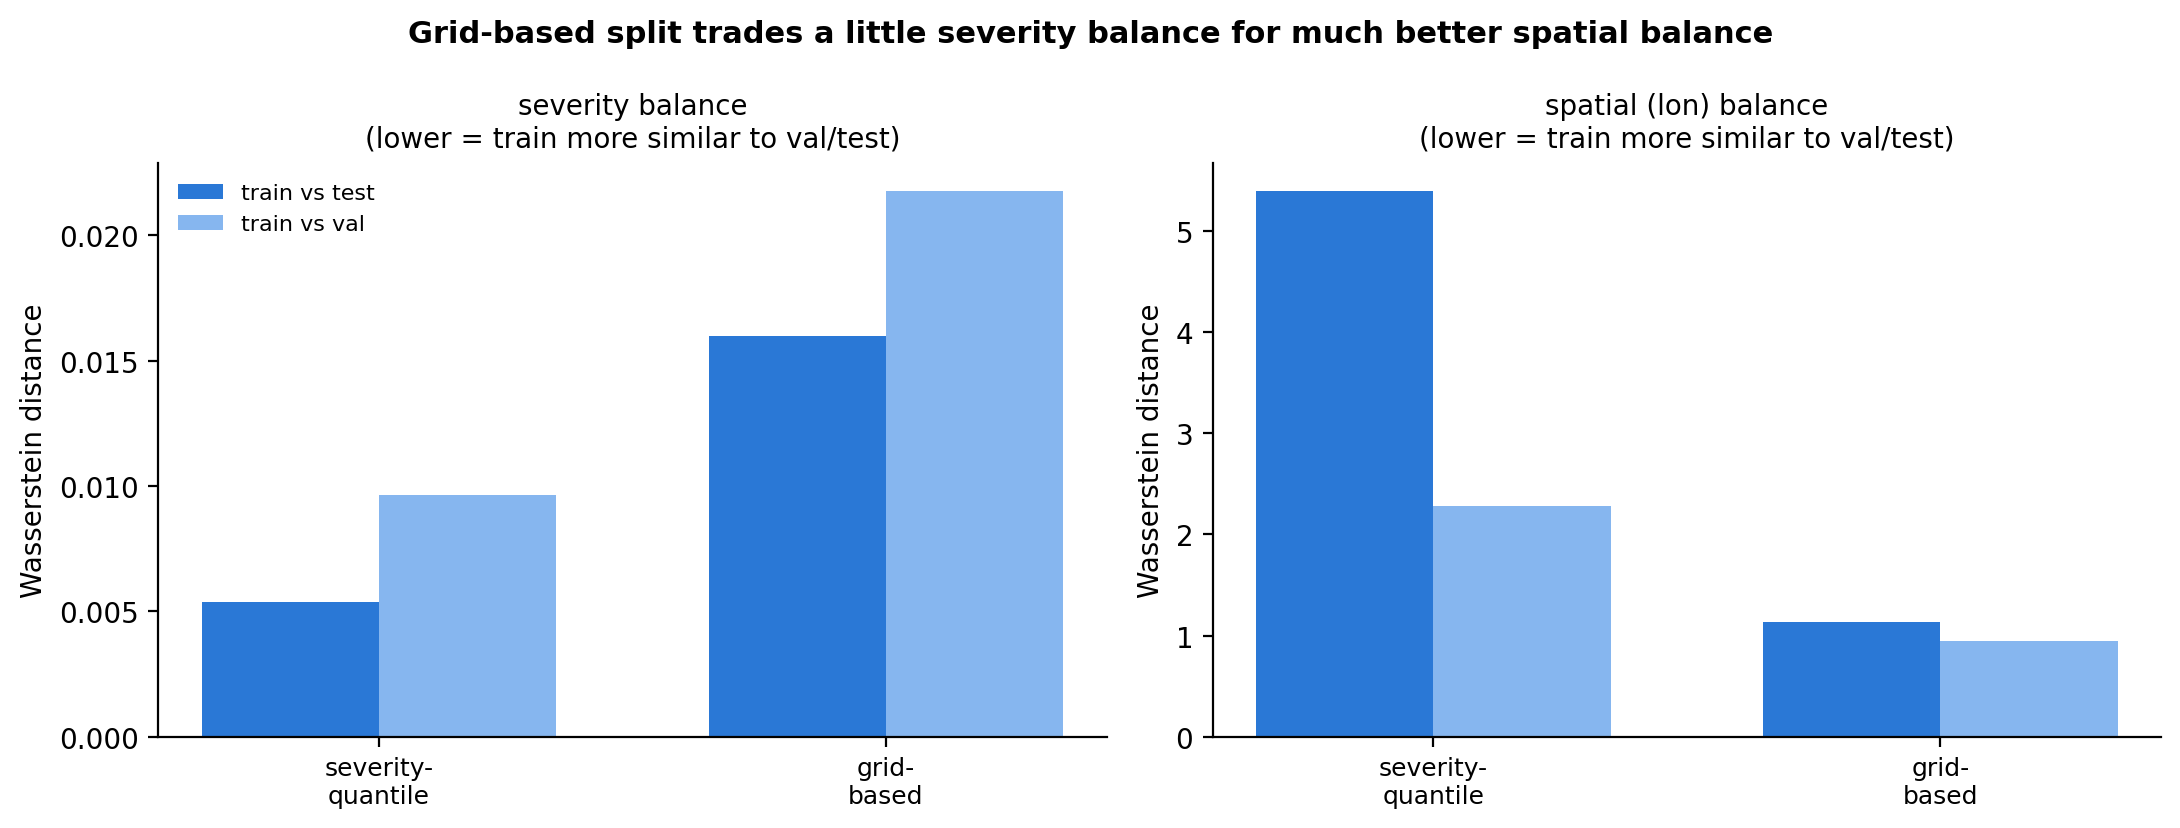

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(2); width = 0.35
for ax, cols, title in [
    (axes[0], ["severity_wass_tr_te", "severity_wass_tr_va"], "severity balance\n(lower = train more similar to val/test)"),
    (axes[1], ["lon_wass_tr_te", "lon_wass_tr_va"], "spatial (lon) balance\n(lower = train more similar to val/test)"),
]:
    ax.bar(x - width / 2, balance[cols[0]], width, color="#2a78d6", label="train vs test")
    ax.bar(x + width / 2, balance[cols[1]], width, color="#86b6ef", label="train vs val")
    ax.set_xticks(x); ax.set_xticklabels(["severity-\nquantile", "grid-\nbased"], fontsize=9)
    ax.set_title(title, fontsize=10); ax.set_ylabel("Wasserstein distance")
    for s in ["top", "right"]: ax.spines[s].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Grid-based split trades a little severity balance for much better spatial balance", fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/05_balance_tradeoff.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Summary → `split_summary_grid.json`

In [14]:
import json
summary = {
    "seed": SEED, "ratios": list(RATIOS), "grid_size_deg": GRID_SIZE_DEG,
    "min_events_per_cell": MIN_EVENTS_PER_CELL, "n_raw_cells": int(n_raw_cells), "n_final_strata": int(n_final_cells),
    "ood_unit": OOD_UNIT, "ood_regions": OOD_REGIONS,
    "events": {sp: int((events["split_grid"] == sp).sum()) for sp in ("train", "val", "test", "ood_holdout")},
    "chips": {sp: int((manifest_grid["split"] == sp).sum()) for sp in ("train", "val", "test", "ood_holdout")},
    "balance_wasserstein": balance.round(4).to_dict("index"),
    "leakage_check": {"events_in_multiple_splits": leaked, "passed": len(leaked) == 0},
}
with open(f"{OUTPUT_DIR}/split_summary_grid.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))

{
  "seed": 42,
  "ratios": [
    0.6,
    0.2,
    0.2
  ],
  "grid_size_deg": 10.0,
  "min_events_per_cell": 15,
  "n_raw_cells": 72,
  "n_final_strata": 28,
  "ood_unit": "country",
  "ood_regions": {
    "burnt": [
      "South Africa"
    ]
  },
  "events": {
    "train": 862,
    "val": 288,
    "test": 291,
    "ood_holdout": 22
  },
  "chips": {
    "train": 2828,
    "val": 961,
    "test": 926,
    "ood_holdout": 71
  },
  "balance_wasserstein": {
    "severity-quantile (current)": {
      "severity_wass_tr_te": 0.0054,
      "severity_wass_tr_va": 0.0097,
      "lon_wass_tr_te": 5.3953,
      "lon_wass_tr_va": 2.2829,
      "lat_wass_tr_te": 0.8775,
      "lat_wass_tr_va": 0.9292
    },
    "grid-based (new)": {
      "severity_wass_tr_te": 0.016,
      "severity_wass_tr_va": 0.0218,
      "lon_wass_tr_te": 1.1305,
      "lon_wass_tr_va": 0.9476,
      "lat_wass_tr_te": 0.6577,
      "lat_wass_tr_va": 0.493
    }
  },
  "leakage_check": {
    "events_in_multiple_splits": [],

## How to use / next steps

1. Tune `GRID_SIZE_DEG` / `MIN_EVENTS_PER_CELL` and re-run from the grid-construction cell if you
   want finer/coarser strata — the diagnostics right after `merge_sparse_cells` print the
   raw-vs-merged cell counts and the final stratum-size distribution to sanity-check the choice.
2. Compare `out/stratification_by_grid_burnt/split_summary_grid.json` against the existing
   `split_summary.json` from `repackage_agdamage_ootd.ipynb` and the balance-trade-off chart above
   to decide whether grid-based is worth adopting over severity-quantile for Burnt.
3. **To replicate for Flood:** copy this notebook, then in the CONFIG cell only change
   `INPUT_PATHS` (Flood's `manifest.parquet`), `OOD_REGIONS` (Flood's already-chosen OOD country,
   e.g. `{"flooded": ["Philippines"]}` — check the current value in
   `repackage_agdamage_ootd.ipynb`/`update_split.py`'s usage comment), and
   `SEVERITY_FIELD_BY_HAZARD`'s hazard string if needed. Everything else (grid construction,
   merge logic, split, all five charts) is hazard-agnostic and runs unchanged.
4. If grid-based is adopted, `manifest_grid.parquet`/`.csv` here is a **standalone artifact** for
   comparison — it does not touch the production `manifest.parquet` under
   `/fs/ess/PGS0413/AgDamage_Benchmark_v2/Burnt/`. Locking it in would mean re-running
   `update_split.py` (or a grid-based variant of it) against the real dataset, including
   `--reshard` to re-pack shards into `shards/<split>/`.